In [2]:
import ee
import math
import matplotlib.pyplot as plt
import re
import os
import glob
import numpy as np
import pandas as pd
ee.Authenticate() #Uncomment this whenever needed, once done usually not needed for 1-2 days
ee.Initialize(project='ee-ictdiitd')

In [3]:
chastainBandNames = ['RED', 'NIR']

# ['BLUE', 'GREEN', 'RED', 'NIR', 'SWIR1', 'SWIR2'

# Regression model parameters from Table-4. MSI TOA reflectance as a function of OLI TOA reflectance.
msiOLISlopes = [1.0524,0.8954]
msiOLIIntercepts = [-0.0015,0.0033]

# Regression model parameters from Table-5. MSI TOA reflectance as a function of ETM+ TOA reflectance.
msiETMSlopes = [1.05681,1.0045]
msiETMIntercepts = [-0.0024,-0.0076]

# Regression model parameters from Table-6. OLI TOA reflectance as a function of ETM+ TOA reflectance.
oliETMSlopes =[1.01991,1.14061]
oliETMIntercepts = [-0.0021,-0.0163]

# Construct dictionary to handle all pairwise combos
chastainCoeffDict = { 'MSI_OLI':[msiOLISlopes,msiOLIIntercepts,1],
                      'MSI_ETM':[msiETMSlopes,msiETMIntercepts,1],
                      'OLI_ETM':[oliETMSlopes,oliETMIntercepts,1],
                      'OLI_MSI':[msiOLISlopes,msiOLIIntercepts,0],
                      'ETM_MSI':[msiETMSlopes,msiETMIntercepts,0],
                      'ETM_OLI':[oliETMSlopes,oliETMIntercepts,0]
                    }

'''
Function to mask cloudy pixels in Landsat-7
'''
def maskL7cloud(image):
  qa = image.select('QA_PIXEL')
  cloudBitMask = qa.bitwiseAnd(1 << 3).eq(0)
  cloudShadowBitMask = qa.bitwiseAnd(1 << 4).eq(0)
  # Both flags should be set to zero, indicating clear conditions.
  mask = cloudBitMask.And(cloudShadowBitMask);
  return image.updateMask(mask).select(['B3' , 'B4']).rename('RED' , 'NIR').copyProperties(image, ['system:time_start'])

'''
Function to mask cloudy pixels in Landsat-8
'''
def maskL7L8cloud(image):
  qa = image.select('QA_PIXEL')
  mask = qa.bitwiseAnd(1 << 2).eq(0).And(qa.bitwiseAnd(1 << 3).eq(0)).And(qa.bitwiseAnd(1 << 4).eq(0))
  return image.updateMask(mask).select(['B4' , 'B5']).rename('RED' , 'NIR').copyProperties(image, ['system:time_start'])


'''
Function to mask clouds using the quality band of Sentinel-2 TOA
'''
def maskS2cloudTOA(image):
  scaled_img = image.select(['B4','B8']).divide(10000)
  qa = image.select('QA60')
  # Bits 10 and 11 are clouds and cirrus, respectively.
  cloudBitMask = 1 << 10
  cirrusBitMask = 1 << 11
  # Both flags should be set to zero, indicating clear conditions.
  mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0));
  return scaled_img.updateMask(mask).select(['B4', 'B8']).rename(['RED', 'NIR']).copyProperties(image, ['system:time_start'])


'''
Get Landsat and Sentinel image collections
'''
def Get_L7_L8_L9_ImageCollections(inputStartDate, inputEndDate, roi_boundary):
  # ------ Landsat 7 TOA
  L7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_TOA') \
          .filterDate(inputStartDate, inputEndDate) \
          .filterBounds(roi_boundary) \
          .select(['B3' , 'B4', 'QA_PIXEL']) \
          .map(maskL7cloud)

  # ------ Landsat 8 TOA
  L8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_TOA") \
          .filterDate(inputStartDate, inputEndDate) \
          .filterBounds(roi_boundary) \
          .select(['B4' , 'B5', 'QA_PIXEL']) \
          .map(maskL7L8cloud)

    # ------ Landsat 8 TOA
  L9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_TOA") \
          .filterDate(inputStartDate, inputEndDate) \
          .filterBounds(roi_boundary) \
          .select(['B4' , 'B5', 'QA_PIXEL']) \
          .map(maskL7L8cloud)

  # # ------ Sentinel-2 TOA
  # S2 = ee.ImageCollection('COPERNICUS/S2_HARMONIZED') \
  #         .filterDate(inputStartDate, inputEndDate) \
  #         .filterBounds(roi_boundary)  \
  #         .select(['B4' , 'B8', 'QA60']) \
  #         .map(maskS2cloudTOA)

  return L7, L8, L9


'''
Function to apply model in one direction
'''
def dir0Regression(img,slopes,intercepts):
  return img.select(chastainBandNames).multiply(slopes).add(intercepts)


'''
Applying the model in the opposite direction
'''
def dir1Regression(img,slopes,intercepts):
  return img.select(chastainBandNames).subtract(intercepts).divide(slopes)


'''
Function to correct one sensor to another
'''
def harmonizationChastain(img, fromSensor,toSensor):
  # Get the model for the given from and to sensor
  comboKey = fromSensor.upper() + '_' + toSensor.upper()
  coeffList = chastainCoeffDict[comboKey]
  slopes = coeffList[0]
  intercepts = coeffList[1]
  direction = ee.Number(coeffList[2])

  # Apply the model in the respective direction
  out = ee.Algorithms.If(direction.eq(0),dir0Regression(img,slopes,intercepts),dir1Regression(img,slopes,intercepts))
  return ee.Image(out).copyProperties(img).copyProperties(img,['system:time_start'])


'''
Calibrate Landsat-8 (OLI) and Sentinel-2 (MSI) to Landsat-7 (ETM+)
'''
def Harmonize_L7_L8_L9(L7, L8, L9):
  # harmonization
  harmonized_L8 = L8.map( lambda img: harmonizationChastain(img, 'OLI','ETM') )
  harmonized_L9 = L9.map( lambda img: harmonizationChastain(img, 'OLI','ETM') )
  # harmonized_S2 = S2.map( lambda img: harmonizationChastain(img, 'MSI','ETM') )

  # Merge harmonized landsat-8 and sentinel-2 to landsat-7 image collection
  harmonized_LandsatSentinel_ic = ee.ImageCollection(L7.merge(harmonized_L8).merge(harmonized_L9))
  return harmonized_LandsatSentinel_ic

def sample_ndvi_ts_ic(ndvi_ic, samples_fc):

    def sample_one(img):
        t = img.get('system:time_start')
        sampled = img.sampleRegions(
            collection=samples_fc,
            scale=30,
            tileScale=4,        # 🔑 prevents memory / geometry failures
            geometries=False
        )
        return sampled.map(lambda f: f.set('timestep', t))

    return ee.FeatureCollection(
        ndvi_ic.map(sample_one)
    ).flatten()

'''
Add NDVI band to harmonized image collection
'''
def addNDVI(image):
  return image.addBands(image.normalizedDifference(['NIR', 'RED']).rename('NDVI')).float()

'''
Function definitions to get NDVI values at each 16-day composites
'''
def Get_NDVI_image_datewise(harmonized_LS_ic):
  def get_NDVI_datewise(date):
    # Convert the date string (which is the start of the 16-day interval) to an ee.Date
    target_date = ee.Date(date)
    # Start the filter 8 days before the interval's start
    startDateT = target_date.advance(-8, 'day')
    # End the filter 8 days after the interval's start (i.e., at the end of the interval)
    endDateT = target_date.advance(8, 'day')

    return harmonized_LS_ic.select(['NDVI']) \
                            .filterDate(startDateT, endDateT) \
                            .median() \
                            .set('system:time_start', target_date.millis())
  return get_NDVI_datewise

''' GET MEDIAN'''
def Get_3YearMedian_NDVI_image_datewise(harmonized_LS_ic):
    def get_NDVI_datewise(date):
        target_date = ee.Date(date)
        dates = ee.List([
            target_date.advance(-1, 'year'),
            target_date,
            target_date.advance(1, 'year')
        ])
        def extract_year(d):
            d = ee.Date(d)
            start = d.advance(-8, 'day')
            end   = d.advance(8, 'day')
            ic = harmonized_LS_ic.select('NDVI').filterDate(start, end)
            # ALWAYS return Float NDVI band
            ndvi = ee.Image(
                ee.Algorithms.If(
                    ic.size().gt(0),
                    ic.median(),
                    ee.Image.constant(-9999).rename('NDVI')
                )
            ).float()
            return ndvi
        # Median across 3 years (still Float)
        ndvi_3yr = ee.ImageCollection(dates.map(extract_year)).median().float()
        # Mask invalid fill values
        ndvi_3yr = ndvi_3yr.updateMask(ndvi_3yr.neq(-9999))
        return ndvi_3yr.set('system:time_start', target_date.millis())

    return get_NDVI_datewise

def Get_LS_16Day_NDVI_TimeSeries(startDate, endDate, harmonized_ic):
    start = ee.Date(startDate)
    end   = ee.Date(endDate)
    n_steps = end.difference(start, 'day').divide(16).floor()
    def make_step(i):
        i = ee.Number(i)
        center_date = start.advance(i.multiply(16), 'day')
        band_name = ee.String('NDVI_').cat(center_date.format('YYYY_MM_dd'))
        years = ee.List([-1, 0, 1])
        def year_image(y):
            y = ee.Number(y)
            d = center_date.advance(y, 'year')
            win_start = d.advance(-8, 'day')
            win_end   = d.advance(8, 'day')
            ic = harmonized_ic \
                .select('NDVI') \
                .filterDate(win_start, win_end)
            empty = (
                ee.Image.constant(0)
                .float()
                .rename('NDVI')
                .updateMask(ee.Image(0))
            )
            return ee.Image(
                ee.Algorithms.If(
                    ic.size().gt(0),
                    ic.median().float(),
                    empty
                )
            )
        ndvi = (
            ee.ImageCollection(years.map(year_image))
            .median()             
            .rename(band_name)    
            .float()
        )
        return ndvi.set('system:time_start', center_date.millis())

    return ee.ImageCollection(
        ee.List.sequence(0, n_steps.subtract(1)).map(make_step)
    )



'''
Add image timestamp to each image in time series
'''
def add_timestamp(image):
  timeImage = image.metadata('system:time_start').rename('timestamp')
  timeImageMasked = timeImage.updateMask(image.mask().select(0))
  return image.addBands(timeImageMasked)


'''
Perform linear interpolation on missing values
'''
def performInterpolation(image):
  image = ee.Image(image)
  beforeImages = ee.List(image.get('before'))
  beforeMosaic = ee.ImageCollection.fromImages(beforeImages).mosaic()
  afterImages = ee.List(image.get('after'))
  afterMosaic = ee.ImageCollection.fromImages(afterImages).mosaic()

  # Interpolation formula
  # y = y1 + (y2-y1)*((t – t1) / (t2 – t1))
  # y = interpolated image
  # y1 = before image
  # y2 = after image
  # t = interpolation timestamp
  # t1 = before image timestamp
  # t2 = after image timestamp

  t1 = beforeMosaic.select('timestamp').rename('t1')
  t2 = afterMosaic.select('timestamp').rename('t2')
  t = image.metadata('system:time_start').rename('t')
  timeImage = ee.Image.cat([t1, t2, t])
  timeRatio = timeImage.expression('(t - t1) / (t2 - t1)', {
                  't': timeImage.select('t'),
                  't1': timeImage.select('t1'),
                  't2': timeImage.select('t2'),
              })

  interpolated = beforeMosaic.add((afterMosaic.subtract(beforeMosaic).multiply(timeRatio)))
  result = image.unmask(interpolated)
  fill_value = ee.ImageCollection([beforeMosaic, afterMosaic]).mosaic()
  result = result.unmask(fill_value)

  return result.copyProperties(image, ['system:time_start'])


def interpolate_timeseries(NDVI_TS):
  filtered = NDVI_TS.map(add_timestamp)

  # Time window in which we are willing to look forward and backward for unmasked pixel in time series
  timeWindow = 120

  # Define a maxDifference filter to find all images within the specified days. Convert days to milliseconds.
  millis = ee.Number(timeWindow).multiply(1000*60*60*24)
  # Filter says that pick only those timestamps which lie between the 2 timestamps not more than millis difference apart
  maxDiffFilter = ee.Filter.maxDifference(
                              difference = millis,
                              leftField = 'system:time_start',
                              rightField = 'system:time_start',
                            )

  # Filter to find all images after a given image. Compare the image's timstamp against other images.
  # Images ahead of target image should have higher timestamp.
  lessEqFilter = ee.Filter.lessThanOrEquals(
                            leftField = 'system:time_start',
                            rightField = 'system:time_start'
                          )

  # Similarly define this filter to find all images before a given image
  greaterEqFilter = ee.Filter.greaterThanOrEquals(
                            leftField = 'system:time_start',
                            rightField = 'system:time_start'
                          )

  # Apply first join to find all images that are after the target image but within the timeWindow
  filter1 = ee.Filter.And( maxDiffFilter, lessEqFilter )
  join1 = ee.Join.saveAll(
                  matchesKey = 'after',
                  ordering = 'system:time_start',
                  ascending = False
          )
  join1Result = join1.apply(
                  primary = filtered,
                  secondary = filtered,
                  condition = filter1
                )

  # Apply first join to find all images that are after the target image but within the timeWindow
  filter2 = ee.Filter.And( maxDiffFilter, greaterEqFilter )
  join2 = ee.Join.saveAll(
                  matchesKey = 'before',
                  ordering = 'system:time_start',
                  ascending = True
          )
  join2Result = join2.apply(
                  primary = join1Result,
                  secondary = join1Result,
                  condition = filter2
                )

  interpolated_S1_TS = ee.ImageCollection(join2Result.map(performInterpolation))

  return interpolated_S1_TS

In [4]:
def get_hierarchical_clusters(ts_dataset, km, NUM_CLUSTERS, THRESHOLD, N_CLUSTER_SPLIT, seed):
  centroids = []
  data_splits = []
  data_to_process = [ts_dataset]
  centroids_to_process = [km.cluster_centers_]  # shape: (K, T, 1)
  # print("centroids_to_process",len(centroids_to_process))
  y_to_process = [km.predict(ts_dataset)]
  num_to_process = [NUM_CLUSTERS]

  while len(data_to_process) > 0:
    data = data_to_process.pop(0)
    rel_centroids = centroids_to_process.pop(0)
    y_pred = y_to_process.pop(0)
    num_clusters = num_to_process.pop(0)
    for _ in range(num_clusters):
      print(f'Processing Cluster {_}')
      relevant_data = data[y_pred == _]
      dist_data = relevant_data[:, :, 0] # (N, T)
      centroid = rel_centroids[_]
      # Ensure centroid is (T,)
      if centroid.ndim == 2:
          centroid = centroid[:, 0]
      elif centroid.ndim == 1:
          pass  # already correct
      else:
          raise ValueError(f"Unexpected centroid shape: {centroid.shape}")
      distances = np.linalg.norm(dist_data - centroid, axis=1)
      distortion = np.mean((distances)**2)
      print("Cluster distortion:", distortion)
      if (distortion <= THRESHOLD):
        centroids.append(centroid)
        data_splits.append(dist_data)
      else:
        km_split = TimeSeriesKMeans(n_clusters=N_CLUSTER_SPLIT, metric="euclidean", n_jobs=32, verbose=False, random_state=seed)
        y_pred_new = km_split.fit_predict(relevant_data)
        num_to_process.append(N_CLUSTER_SPLIT)
        data_to_process.append(relevant_data)
        y_to_process.append(y_pred_new)
        centroids_to_process.append(km_split.cluster_centers_)  # (K, T, 1)
    print('After Popping: ' + str(len(data_to_process)))
  return centroids, data_splits

def plot_single_cluster(idx, centroid, consider):
    distances = np.linalg.norm(consider - centroid, axis=1)

    q05, q25, q75, q95 = np.quantile(distances, [0.05, 0.25, 0.75, 0.95])

    band1 = consider[(distances >= q05) & (distances <= q95)]
    band2 = consider[(distances >= q25) & (distances <= q75)]

    T = centroid.shape[0]
    x = np.arange(T)

    plt.figure(figsize=(10, 6), dpi=120)
    plt.fill_between(x, band1.max(axis=0), band1.min(axis=0), alpha=0.2)
    plt.fill_between(x, band2.max(axis=0), band2.min(axis=0), alpha=0.5)
    plt.plot(x, centroid, "r-", linewidth=2)

    plt.axhline(0.35, linestyle="--", color="g")
    plt.ylim(-0.2, 1.0)
    plt.xlabel("Time step (16-day)")
    plt.ylabel("NDVI")
    plt.title(f"Cluster {idx+1}")
    plt.grid(True)
    plt.show()
def display_clusters(centroids, data_splits, sz):
  fig = plt.figure(figsize=(50, 20), dpi=80)
  splits = 4
  def on_click(event):
    ax = event.inaxes
    if ax is None:
        return
    idx = ax._cluster_idx
    plot_single_cluster(idx, centroids[idx], data_splits[idx])
  # splits = math.ceil( int( len(centroids)/10 ) )
  n_plots = len(centroids)
  print("Number of centroids are: ",n_plots)
  for idx, centroid in enumerate(centroids):
      try:
        ax = plt.subplot(splits, (n_plots+splits-1)//splits, idx + 1)
        ax._cluster_idx = idx

        plt.rc('font', size=16)
        plt.rc('xtick', labelsize=14)
        plt.rc('ytick', labelsize=14)

        consider = data_splits[idx]   # (N, T)
        centroid = centroids[idx]     # (T,)

        distances = np.linalg.norm(consider - centroid, axis=1)
        q05, q25, q75, q95 = np.quantile(distances, [0.05, 0.25, 0.75, 0.95])

        band1 = consider[(distances >= q05) & (distances <= q95)]
        band2 = consider[(distances >= q25) & (distances <= q75)]

        T = centroid.shape[0]
        x = np.arange(T)

        plt.fill_between(x, band1.max(axis=0), band1.min(axis=0), alpha=0.2)
        plt.fill_between(x, band2.max(axis=0), band2.min(axis=0), alpha=0.5)
        plt.plot(x, centroid, "r-")
        plt.xlim(0, T - 1)
        plt.ylim(-0.2, 1.0)
        plt.axhline(y=0.35, color='g', linestyle='--')
        ax.xaxis.set_ticks(np.arange(0, T, 4))

      except Exception as e:
        print(e)
  fig.canvas.mpl_connect('button_press_event', on_click)
  plt.show()



In [5]:
REFERENCE_DATE = '2020-07-01'   # start of your 3-year window
START_DATE     = '2020-07-01'
END_DATE       = '2023-06-30'
HARMONIC_BANDS = ['constant', 'sin_ann', 'cos_ann', 'sin_sem', 'cos_sem']
countries  = ee.FeatureCollection('FAO/GAUL_SIMPLIFIED_500m/2015/level0')
india = countries.filter(ee.Filter.eq('ADM0_NAME', 'India')).first().geometry()
s2_grids = ee.FeatureCollection("projects/ee-ojasvibansal/assets/s2_level13_india")
s2grids_cluster = ee.FeatureCollection("projects/ee-ojasvibansal/assets/s2_level13_india_clustered_k8")
lulc = ee.Image("projects/corestack-datasets/assets/datasets/LULC_v3_river_basin/pan_india_lulc_v3_2022_2023")
# ── Step 1: Build 3-year Landsat NDVI time series ─────────────────────────────
L7, L8, L9 = Get_L7_L8_L9_ImageCollections(
    ee.Date(START_DATE).advance(-16, 'day'),
    ee.Date(END_DATE).advance(16, 'day'),
    india
)
harmonized = Harmonize_L7_L8_L9(L7, L8, L9).map(addNDVI)
ndvi_ts_3yr = Get_LS_16Day_NDVI_TimeSeries(
    ee.Date(START_DATE),
    ee.Date(END_DATE),
    harmonized
)  
# ── Step 2: Add harmonic bands to each image ──────────────────────────────────
def add_harmonic_bands(img):
    ndvi_band = img.bandNames().filter(ee.Filter.stringStartsWith('item', 'NDVI')).get(0)
    img = img.rename(img.bandNames().replace(ndvi_band, 'NDVI'))
    t    = img.date().difference(ee.Date(REFERENCE_DATE), 'year')
    tImg = ee.Image(t).float().multiply(2 * math.pi).rename('t')
    return img.addBands([
        ee.Image(1).double().rename('constant'),
        tImg,
        tImg.sin().rename('sin_ann'),
        tImg.cos().rename('cos_ann'),
        tImg.multiply(2).sin().rename('sin_sem'),
        tImg.multiply(2).cos().rename('cos_sem'),
    ])
harmonic_ts = ndvi_ts_3yr.map(add_harmonic_bands)

# ── Step 3: Fit harmonic regression per pixel ─────────────────────────────────
independents = ['constant', 't', 'sin_ann', 'cos_ann', 'sin_sem', 'cos_sem']

regression = (
    harmonic_ts.select(independents + ['NDVI'])
               .reduce(ee.Reducer.linearRegression(len(independents), 1))
)

# Extract coefficients: one image with 6 bands
harmonic_coeffs = (
    regression.select('coefficients')
              .arrayProject([0])
              .arrayFlatten([independents])
              .select(HARMONIC_BANDS)   # drop 't' — not useful for clustering
              .clip(india)
)

# task = ee.batch.Export.image.toAsset(
#     image       = harmonic_coeffs.toFloat(),
#     description = 'harmonic_coeffs_ndvi_2020_2023',
#     assetId     = 'projects/ee-ictdiitd/assets/apoorva/harmonic_coeffs_ndvi_2020_2023',
#     region      = india,
#     scale       = 30,
#     maxPixels   = 1e13,
#     pyramidingPolicy = {'.default': 'mean'}
# )
# task.start()
# print(f"Asset export started: {task.id}")

# Split India into a 3×3 grid of tiles
def get_india_tiles():
    # India bounding box approx: lon 68-97, lat 8-37
    lon_splits = [68, 78, 88, 97]
    lat_splits = [8,  18, 28, 37]
    tiles = []
    for i in range(3):
        for j in range(3):
            tile = ee.Geometry.Rectangle([
                lon_splits[i], lat_splits[j],
                lon_splits[i+1], lat_splits[j+1]
            ])
            tiles.append((f'tile_{i}_{j}', tile))
    return tiles

tiles = get_india_tiles()
tasks = {}
tile_images = [
    ee.Image(f'projects/ee-ictdiitd/assets/apoorva/harmonic_coeffs_ndvi_2020_2023_tile_{i}_{j}')
    for i in range(3) for j in range(3)
]
harmonic_coeffs = ee.ImageCollection(tile_images).mosaic().clip(india)
# harmonic_coeffs has 5 bands: constant, sin_ann, cos_ann, sin_sem, cos_sem

# for tile_name, tile_geom in tiles:
#     asset_id = f'projects/ee-ictdiitd/assets/apoorva/harmonic_coeffs_ndvi_2020_2023_{tile_name}'
#     t = ee.batch.Export.image.toAsset(
#         image       = harmonic_coeffs.toFloat().clip(tile_geom),
#         description = f'harmonic_coeffs_{tile_name}',
#         assetId     = asset_id,
#         region      = tile_geom,
#         scale       = 30,
#         maxPixels   = 1e13,
#         pyramidingPolicy = {'.default': 'mean'}
#     )
#     t.start()
#     tasks[tile_name] = t
#     print(f"Submitted: {tile_name} → {asset_id}")

# print(f"\n{len(tasks)} tile tasks submitted")

In [4]:

sampled_grids  = s2_grids.randomColumn(seed=42).sort('random').limit(20000)
all_grid_ids   = sampled_grids.aggregate_array('s2_id')
lulc_classes_codes = {
    'tree'  : [6],
    'shrub' : [12]
}

harmonic_and_lulc = harmonic_coeffs.addBands(lulc.rename('lulc_label'))
def sample_harmonic_for_class(grid, lulc_codes, cls_name):
    codes_ee = ee.List(lulc_codes)
    mask     = lulc.remap(codes_ee, ee.List.repeat(1, codes_ee.length()), 0)
    samples  = harmonic_and_lulc.updateMask(mask) \
        .sample(
            region    = grid.geometry(),
            numPixels = 100,
            scale     = 30,
            geometries= True,
            seed      = 42
        )
    return samples.map(lambda f: f.set({
        'grid_id'   : grid.get('s2_id'),
        'lulc_class': cls_name,
    }))

BATCH_SIZE = 200
num_batches = 100  # 100 × 200 = 20,000 grids

for cls_name, lulc_codes in lulc_classes_codes.items():
    print(f"\nSubmitting harmonic export tasks for: {cls_name}")
    for batch_index in range(num_batches):
        batch_ids   = all_grid_ids.slice(
            batch_index * BATCH_SIZE,
            (batch_index + 1) * BATCH_SIZE
        )
        batch_grids   = sampled_grids.filter(ee.Filter.inList('s2_id', batch_ids))
        batch_samples = batch_grids.map(
            lambda g: sample_harmonic_for_class(g, lulc_codes, cls_name)
        ).flatten()

        task = ee.batch.Export.table.toDrive(
            collection     = batch_samples,
            description    = f'harmonic_{cls_name}_batch_{batch_index:03d}',
            folder         = f'GEE_Harmonic_{cls_name}',
            fileNamePrefix = f'harmonic_{cls_name}_batch_{batch_index:03d}',
            fileFormat     = 'CSV'
        )
        task.start()
    print(f"  → {num_batches} tasks submitted for {cls_name}")



Submitting harmonic export tasks for: tree
  → 100 tasks submitted for tree

Submitting harmonic export tasks for: shrub
  → 100 tasks submitted for shrub


In [6]:
def build_harmonic_matrix(df):
    coeff_cols = ['constant', 'sin_ann', 'cos_ann', 'sin_sem', 'cos_sem']
    
    # verify all present
    missing = [c for c in coeff_cols if c not in df.columns]
    if missing:
        print(f"Missing columns: {missing}. Available: {df.columns.tolist()}")
        return pd.DataFrame()
    
    X = df[coeff_cols].astype(float).dropna()
    print(f"Harmonic feature matrix shape: {X.shape}")
    return X
def load_class_csvs(cls_name, folder='.'):
    files = sorted(glob.glob(f"{folder}/harmonic_{cls_name}_batch_*.csv"))
    print(f"  [{cls_name}] Found {len(files)} files in {folder}")
    dfs, skipped = [], []
    for f in files:
        if os.path.getsize(f) == 0:
            skipped.append(f); continue
        try:
            df = pd.read_csv(f)
            if df.empty or df.shape[1] == 0:
                skipped.append(f); continue
            dfs.append(df)
        except pd.errors.EmptyDataError:
            skipped.append(f)
    if skipped:
        print(f"  [{cls_name}] Skipped {len(skipped)} empty files")
    df_out = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    print(f"  [{cls_name}] {len(df_out):>10,} rows loaded from {len(dfs)} files")
    return df_out
# Load CSVs (same load_class_csvs function as before, new folder)
trees_df  = load_class_csvs('tree',  folder='./GEE_Harmonic_tree')
shrubs_df = load_class_csvs('shrub', folder='./GEE_Harmonic_shrub')

X_tree  = build_harmonic_matrix(trees_df)
X_shrub = build_harmonic_matrix(shrubs_df)

# ── Clustering (sklearn KMeans, not tslearn — features are flat not time series)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def fit_kmeans(X, k, cls_name):
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(X)
    km        = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels    = km.fit_predict(X_scaled)
    print(f"{cls_name}: k={k}, inertia={km.inertia_:.2f}")
    return km, scaler, labels

km_tree,  scaler_tree,  labels_tree  = fit_kmeans(X_tree,  k=8, cls_name='tree')
km_shrub, scaler_shrub, labels_shrub = fit_kmeans(X_shrub, k=5, cls_name='shrub')

  [tree] Found 99 files in ./GEE_Harmonic_tree
  [tree]    627,981 rows loaded from 99 files
  [shrub] Found 100 files in ./GEE_Harmonic_shrub
  [shrub]     78,972 rows loaded from 100 files
Harmonic feature matrix shape: (627981, 5)
Harmonic feature matrix shape: (78972, 5)
tree: k=8, inertia=1414010.52
shrub: k=5, inertia=177952.35



── SHRUB ──


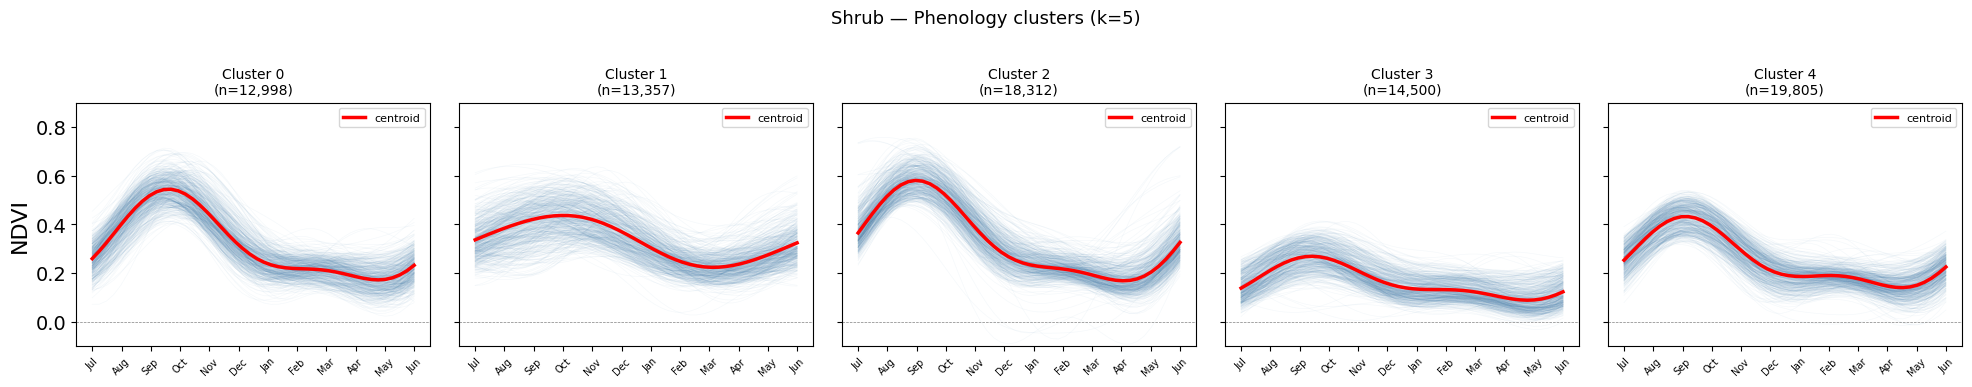

C:\Users\hp\AppData\Local\Temp\ipykernel_360\3814032031.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'C{i}' for i in range(k)], patch_artist=True,
C:\Users\hp\AppData\Local\Temp\ipykernel_360\3814032031.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'C{i}' for i in range(k)], patch_artist=True,
C:\Users\hp\AppData\Local\Temp\ipykernel_360\3814032031.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'C{i}' for i in range(k)], patch_artist=True,
C:\Users\hp\AppData\Local\Temp\ipykernel_360\3814032031.py:68: MatplotlibDeprecati

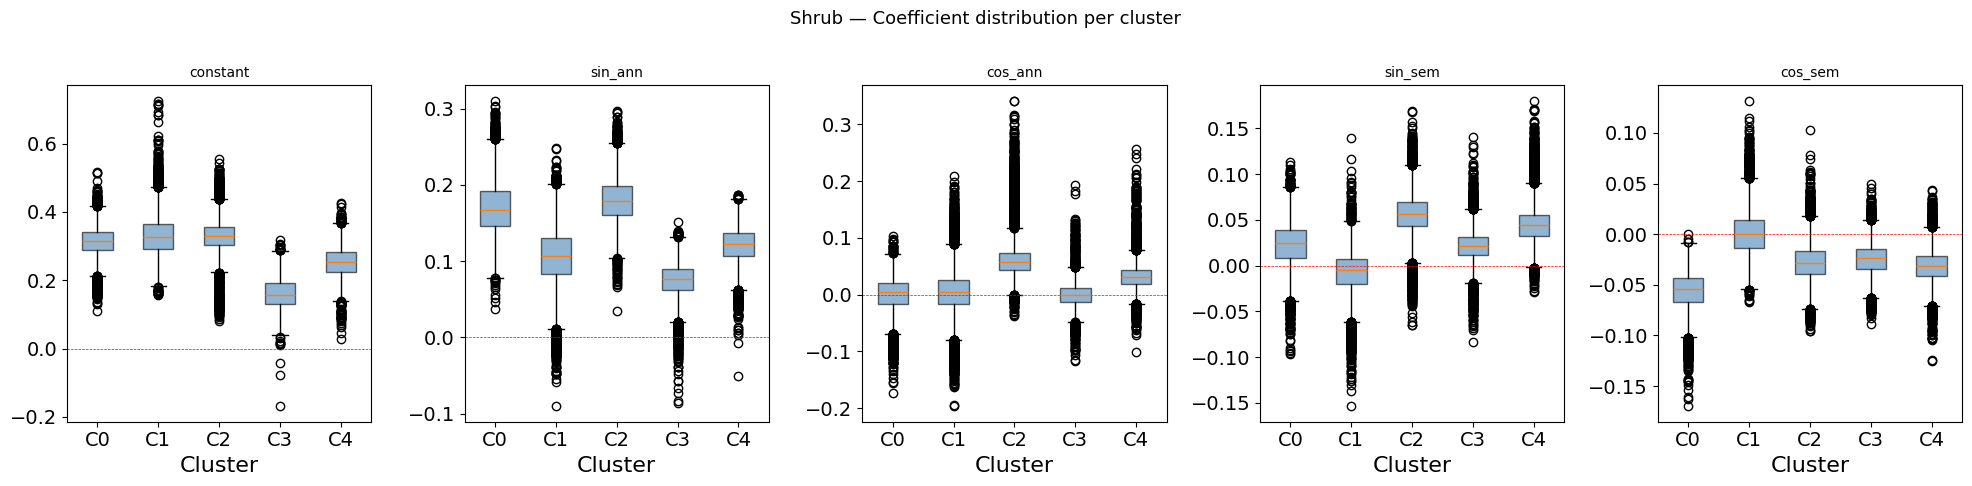

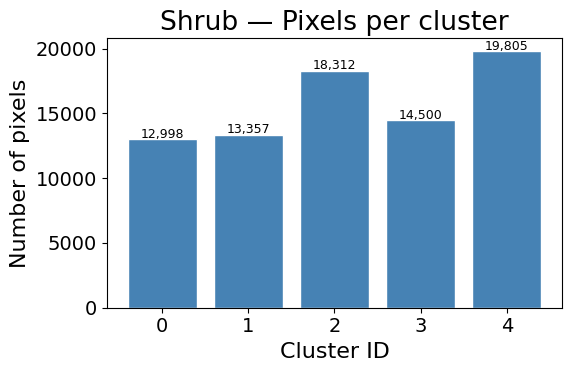

In [ ]:
# ── Reconstruct phenology curve from coefficient vector ───────────────────────
def reconstruct_curve(coeffs, n_points=46):
    """coeffs: array [constant, sin_ann, cos_ann, sin_sem, cos_sem]"""
    t     = np.linspace(0, 1, n_points, endpoint=False)
    omega = 2 * math.pi
    return (
        coeffs[0]
        + coeffs[1] * np.sin(omega * t)
        + coeffs[2] * np.cos(omega * t)
        + coeffs[3] * np.sin(2 * omega * t)
        + coeffs[4] * np.cos(2 * omega * t)
    )

month_labels = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun']

# ── Plot 1: Centroid phenology curves ─────────────────────────────────────────
def plot_centroid_curves(km, scaler, labels, X, cls_name, n_points=46):
    k = km.n_clusters
    # centroids are in scaled space — inverse transform back to original
    centroids_original = scaler.inverse_transform(km.cluster_centers_)
    
    fig, axes = plt.subplots(1, k, figsize=(4*k, 4), sharey=True)
    if k == 1: axes = [axes]
    
    t = np.linspace(0, 1, n_points, endpoint=False)
    
    for i, ax in enumerate(axes):
        centroid_curve = reconstruct_curve(centroids_original[i], n_points)
        cluster_mask   = labels == i
        n_pixels       = cluster_mask.sum()
        
        # plot individual pixel curves (subsample to avoid overplotting)
        subsample = X[cluster_mask].values
        if len(subsample) > 500:
            idx       = np.random.choice(len(subsample), 500, replace=False)
            subsample = subsample[idx]
        
        for row in subsample:
            curve = reconstruct_curve(row, n_points)
            ax.plot(curve, color='steelblue', alpha=0.05, linewidth=0.5)
        
        # plot centroid on top
        ax.plot(centroid_curve, color='red', linewidth=2.5, label='centroid')
        
        ax.set_title(f'Cluster {i}\n(n={n_pixels:,})', fontsize=10)
        ax.set_xticks(np.linspace(0, n_points-1, 12))
        ax.set_xticklabels(month_labels, rotation=45, fontsize=7)
        ax.set_ylim(-0.1, 0.9)
        ax.set_ylabel('NDVI' if i == 0 else '')
        ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
        ax.legend(fontsize=8)
    
    plt.suptitle(f'{cls_name.capitalize()} — Phenology clusters (k={k})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'clusters_{cls_name}_curves.png', dpi=150)
    plt.show()


# ── Plot 2: Boxplots of each harmonic coefficient per cluster ─────────────────
def plot_coefficient_boxplots(X, labels, cls_name):
    coeff_cols = ['constant', 'sin_ann', 'cos_ann', 'sin_sem', 'cos_sem']
    k          = len(np.unique(labels))
    
    fig, axes = plt.subplots(1, len(coeff_cols), figsize=(4*len(coeff_cols), 5))
    
    for ax, col in zip(axes, coeff_cols):
        data = [X[col].values[labels == i] for i in range(k)]
        ax.boxplot(data, labels=[f'C{i}' for i in range(k)], patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('Cluster')
        ax.axhline(0, color='red', linewidth=0.5, linestyle='--')
    
    plt.suptitle(f'{cls_name.capitalize()} — Coefficient distribution per cluster', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'clusters_{cls_name}_boxplots.png', dpi=150)
    plt.show()


# ── Plot 3: Cluster size bar chart ────────────────────────────────────────────
def plot_cluster_sizes(labels, cls_name):
    unique, counts = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6, 4))
    plt.bar(unique, counts, color='steelblue', edgecolor='white')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of pixels')
    plt.title(f'{cls_name.capitalize()} — Pixels per cluster')
    for u, c in zip(unique, counts):
        plt.text(u, c + 100, f'{c:,}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'clusters_{cls_name}_sizes.png', dpi=150)
    plt.show()


# ── Run all plots ─────────────────────────────────────────────────────────────
for cls_name, km, scaler, labels, X in [
    ('tree',  km_tree,  scaler_tree,  labels_tree,  X_tree),
    ('shrub', km_shrub, scaler_shrub, labels_shrub, X_shrub),
]:
    print(f"\n── {cls_name.upper()} ──")
    plot_centroid_curves(km, scaler, labels, X, cls_name)
    plot_coefficient_boxplots(X, labels, cls_name)
    plot_cluster_sizes(labels, cls_name)

## Assigning clusters to grids

In [7]:
centroids_tree_original  = scaler_tree.inverse_transform(km_tree.cluster_centers_)
centroids_shrub_original = scaler_shrub.inverse_transform(km_shrub.cluster_centers_)

WINDOW_YEARS = [2003, 2004]  # example: expand as needed, e.g. range(2003, 2024)

def build_harmonic_coeffs_for_window(end_year, window_size=3):
    """
    Builds harmonic coefficients using a `window_size`-year window
    ending at `end_year`. E.g. end_year=2003, window_size=3
    → uses data from 2001-07-01 to 2004-06-30
    """
    start_year = end_year - window_size + 1
    start = ee.Date.fromYMD(start_year, 7, 1)
    end   = ee.Date.fromYMD(end_year + 1, 6, 30)

    L7, L8, L9 = Get_L7_L8_L9_ImageCollections(
        start.advance(-16, 'day'),
        end.advance(16, 'day'),
        india
    )
    harmonized = Harmonize_L7_L8_L9(L7, L8, L9).map(addNDVI)
    ndvi_ts    = Get_LS_16Day_NDVI_TimeSeries(start, end, harmonized)

    def add_harmonic_bands(img):
        ndvi_band = img.bandNames().filter(ee.Filter.stringStartsWith('item', 'NDVI')).get(0)
        img  = img.rename(img.bandNames().replace(ndvi_band, 'NDVI'))
        t    = img.date().difference(ee.Date(REFERENCE_DATE), 'year')
        tImg = ee.Image(t).float().multiply(2 * math.pi).rename('t')
        return img.addBands([
            ee.Image(1).double().rename('constant'),
            tImg,
            tImg.sin().rename('sin_ann'),
            tImg.cos().rename('cos_ann'),
            tImg.multiply(2).sin().rename('sin_sem'),
            tImg.multiply(2).cos().rename('cos_sem'),
        ])

    harmonic_ts  = ndvi_ts.map(add_harmonic_bands)
    independents = ['constant', 't', 'sin_ann', 'cos_ann', 'sin_sem', 'cos_sem']
    regression   = (
        harmonic_ts.select(independents + ['NDVI'])
                   .reduce(ee.Reducer.linearRegression(len(independents), 1))
    )
    coeffs = (
        regression.select('coefficients')
                  .arrayProject([0])
                  .arrayFlatten([independents])
                  .select(HARMONIC_BANDS)
                  .clip(india)
                  .toFloat()
    )
    return coeffs

def build_harmonic_coeffs_for_window_masked(end_year, lulc_codes_combined, window_size=3):
    coeffs = build_harmonic_coeffs_for_window(end_year, window_size)
    mask = lulc.remap(
        ee.List(lulc_codes_combined),
        ee.List.repeat(1, len(lulc_codes_combined)),
        0
    ).selfMask()
    return coeffs.updateMask(mask)

# combine tree (6) and shrub (12) codes since both need this asset
combined_codes = [6, 12]
ASSET_DIR = 'projects/ee-ictdiitd/assets/apoorva'
lulc_classes_info = {
    'tree' : {'codes': [6],  'centroids': centroids_tree_original},
    'shrub': {'codes': [12], 'centroids': centroids_shrub_original},
}

def get_india_tiles():
    lon_splits = [68, 78, 88, 97]
    lat_splits = [8,  18, 28, 37]
    tiles = []
    for i in range(3):
        for j in range(3):
            tile = ee.Geometry.Rectangle([
                lon_splits[i], lat_splits[j],
                lon_splits[i+1], lat_splits[j+1]
            ])
            tiles.append((f'tile_{i}_{j}', tile))
    return tiles

tiles = get_india_tiles()

def submit_tiled_window_export(end_year, combined_codes, window_size=3):
    all_tile_tasks = {}
    for tile_name, tile_geom in tiles:
        coeffs_masked = build_harmonic_coeffs_for_window_masked(end_year, combined_codes, window_size)
        asset_id = f'{ASSET_DIR}/harmonic_coeffs_window_{end_year}_{tile_name}'
        
        task = ee.batch.Export.image.toAsset(
            image       = coeffs_masked.toFloat().clip(tile_geom),
            description = f'harmonic_coeffs_window_{end_year}_{tile_name}',
            assetId     = asset_id,
            region      = tile_geom,
            scale       = 30,
            maxPixels   = 1e13,
            pyramidingPolicy = {'.default': 'mean'}
        )
        task.start()
        all_tile_tasks[f'{end_year}_{tile_name}'] = task
        print(f"  Submitted: {end_year} {tile_name}")
    return all_tile_tasks

# Resubmit for your 2 stuck years, tiled this time
all_tasks = {}
for end_year in WINDOW_YEARS:  # [2003, 2004]
    print(f"\n[window ending {end_year}]")
    tile_tasks = submit_tiled_window_export(end_year, combined_codes, window_size=3)
    all_tasks.update(tile_tasks)

print(f"\n{len(all_tasks)} tile tasks submitted total")


[window ending 2003]
  Submitted: 2003 tile_0_0
  Submitted: 2003 tile_0_1
  Submitted: 2003 tile_0_2
  Submitted: 2003 tile_1_0
  Submitted: 2003 tile_1_1
  Submitted: 2003 tile_1_2
  Submitted: 2003 tile_2_0
  Submitted: 2003 tile_2_1
  Submitted: 2003 tile_2_2

[window ending 2004]
  Submitted: 2004 tile_0_0
  Submitted: 2004 tile_0_1
  Submitted: 2004 tile_0_2
  Submitted: 2004 tile_1_0
  Submitted: 2004 tile_1_1
  Submitted: 2004 tile_1_2
  Submitted: 2004 tile_2_0
  Submitted: 2004 tile_2_1
  Submitted: 2004 tile_2_2

18 tile tasks submitted total


In [ ]:
def mosaic_window_tiles(end_year):
    tile_images = [
        ee.Image(f'{ASSET_DIR}/harmonic_coeffs_window_{end_year}_tile_{i}_{j}')
        for i in range(3) for j in range(3)
    ]
    mosaicked = ee.ImageCollection(tile_images).mosaic().clip(india)
    
    # save the mosaic as the final single asset (matches naming your sampling code expects)
    task = ee.batch.Export.image.toAsset(
        image       = mosaicked.toFloat(),
        description = f'harmonic_coeffs_window_{end_year}_final',
        assetId     = f'{ASSET_DIR}/harmonic_coeffs_window_{end_year}',
        region      = india,
        scale       = 30,
        maxPixels   = 1e13,
        pyramidingPolicy = {'.default': 'mean'}
    )
    task.start()
    print(f"Mosaic export submitted for {end_year}")
    return task

# after all tiles for a year complete:
# mosaic_window_tiles(2003)
# mosaic_window_tiles(2004)

In [ ]:
# ── Step 2: Assign cluster to each pixel using nearest centroid ───────────────
def make_cluster_image_from_centroids(coeffs_img, centroids_np, cls_name):
    """
    For each pixel, compute distance to each centroid in coefficient space
    and assign the nearest one.
    centroids_np: shape (k, 5) in ORIGINAL (unscaled) space
    """
    band_names = ee.List(HARMONIC_BANDS)
    k          = len(centroids_np)

    distance_images = []
    for i, centroid in enumerate(centroids_np):
        centroid_img = ee.Image.constant(centroid.tolist()).rename(band_names)
        dist = (
            coeffs_img.subtract(centroid_img)
                      .pow(2)
                      .reduce(ee.Reducer.sum())
                      .sqrt()
                      .rename('distance')
        )
        cluster_id_img = ee.Image.constant(i).rename('cluster_id').toInt()
        distance_images.append(dist.addBands(cluster_id_img))

    dist_ic = ee.ImageCollection(distance_images)
    cluster_img = (
        dist_ic.map(lambda img: img.addBands(
            img.select('distance').multiply(-1).rename('neg_distance')
        ))
        .qualityMosaic('neg_distance')
        .select('cluster_id')
        .toInt()
    )
    return cluster_img

# ── Use window-based asset IDs and naming ──────────────────────────────────────
WINDOW_YEARS = [2003,2004]  # these are end_years of the 3-year windows
def submit_grid_cluster_exports(drive_folder='GEE_Stability_3yr'):
    all_tasks = {}

    for end_year in WINDOW_YEARS:
        print(f"\n[window ending {end_year}]")
        coeffs_img = ee.Image(f'{ASSET_DIR}/harmonic_coeffs_window_{end_year}')

        for cls_name, info in lulc_classes_info.items():
            centroids_np = info['centroids']
            lulc_codes   = info['codes']

            # build lulc mask for this class
            lulc_mask   = lulc.remap(
                ee.List(lulc_codes),
                ee.List.repeat(1, len(lulc_codes)),
                0
            ).selfMask()

            # assign cluster per pixel
            cluster_img = make_cluster_image_from_centroids(
                coeffs_img.updateMask(lulc_mask),
                centroids_np,
                cls_name
            )

            # majority vote per grid via reduceRegions
            grid_clusters = cluster_img.reduceRegions(
                collection = s2_grids,
                reducer    = ee.Reducer.mode(),
                scale      = 30,
                tileScale  = 4
            )

            # keep only grid_id and cluster
            grid_clusters = grid_clusters.map(lambda f: ee.Feature(None).set({
                'grid_id'   : f.get('s2_id'),
                'cluster_id': f.get('mode')
            }))

            task = ee.batch.Export.table.toDrive(
                collection  = grid_clusters,
                description = f'stability_{cls_name}_window_{end_year}',
                folder      = drive_folder,
                fileFormat  = 'CSV',
                selectors   = ['grid_id', 'cluster_id']
            )
            task.start()
            all_tasks[f'{end_year}_{cls_name}'] = task
            print(f"  Submitted: {cls_name} window_{end_year}")

    print(f"\n{len(all_tasks)} tasks submitted total")
    return all_tasks

tasks = submit_grid_cluster_exports()


[2009]
  Submitted: tree 2009
  Submitted: shrub 2009

[2010]
  Submitted: tree 2010
  Submitted: shrub 2010

4 tasks submitted total
